In [1]:
!pip install scikit-learn numpy matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


### Loading and normalizing dataset

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784', as_frame=False)
mnist_X = mnist.data.astype('float32') / 255.0
mnist_y = mnist.target.astype('int64')

In [11]:
# Digits 0–5: phases 1 (first half) and 2 (second half)
mask_0_to_5 = (mnist_y >= 0) & (mnist_y <= 5)
X_05, y_05 = mnist_X[mask_0_to_5], mnist_y[mask_0_to_5]
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(
    X_05, y_05, test_size=0.2, random_state=42, stratify=y_05
)
mid = len(X_train_05) // 2
X_train_half1, y_train_half1 = X_train_05[:mid], y_train_05[:mid]
X_train_half2, y_train_half2 = X_train_05[mid:], y_train_05[mid:]

# Digits 6–9: phase 3 (new classes)
mask_6_to_9 = (mnist_y >= 6) & (mnist_y <= 9)
X_69, y_69 = mnist_X[mask_6_to_9], mnist_y[mask_6_to_9]
X_train_69, X_test_69, y_train_69, y_test_69 = train_test_split(
    X_69, y_69, test_size=0.2, random_state=42, stratify=y_69
)

# Whole dataset
X_cp = mnist_X
y_cp = mnist_y
X_train, X_test, y_train, y_test = train_test_split(
    X_cp, y_cp, test_size=0.2, random_state=42, stratify=y_cp
)

print(f"Digits 0-5 — train: {len(X_train_05)}, test: {len(X_test_05)}")
print(f"  Half 1: {len(X_train_half1)} | Half 2: {len(X_train_half2)}")
print(f"Digits 6-9 — train: {len(X_train_69)}, test: {len(X_test_69)}")

Digits 0-5 — train: 33638, test: 8410
  Half 1: 16819 | Half 2: 16819
Digits 6-9 — train: 22361, test: 5591


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

n_components = 40
pca = PCA(n_components=n_components, random_state=42)
scaler = StandardScaler()

# Fit only on the first half; transform everything else with the same transform
X_epnn_half1 = scaler.fit_transform(pca.fit_transform(X_train_half1))
X_epnn_half2 = scaler.transform(pca.transform(X_train_half2))
X_epnn_train_69 = scaler.transform(pca.transform(X_train_69))
X_epnn_test_05 = scaler.transform(pca.transform(X_test_05))
X_epnn_test_69 = scaler.transform(pca.transform(X_test_69))

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

PCA explained variance: 80.4%


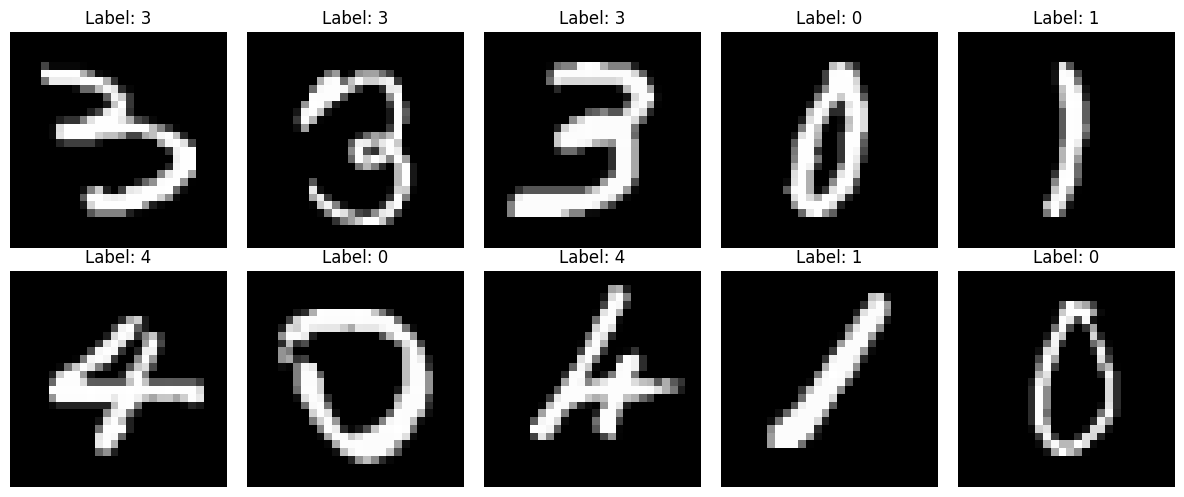

In [4]:
n = 10
idx = np.random.choice(len(X_05), n, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X_05[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_05[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Neural networks code (Art1, FuzzyArt, ePNN)

In [ ]:
class Art1:
    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features
        # β is a small positive constant (often β < 1)
        self.beta = 0.5
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.w_td = np.ones((self.max_clusters, self.num_features))

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # zₖ = ∑ᵢ xᵢ · bᵢₖ
        for j in range(self.num_clusters):
            activations[j] = np.dot(X, self.w_bu[j])
        
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # |x ∩ tₖ|/|x| = ∑ᵢ(xᵢ · tᵢₖ)/∑ᵢxᵢ
        x_sum = np.sum(X)
        if x_sum == 0:
            return False
        match_ratio = np.dot(X, self.w_td[best_cluster]) / x_sum
        # |x ∩ tₖ|/|x| ≥ ρ
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # tᵢₖ(new) = xᵢ · tᵢₖ(old)
        new_t = X * self.w_td[cluster_idx]
        self.w_td[cluster_idx] = new_t
        # bᵢₖ(new) = β/(β + |tₖ(new)|) · tᵢₖ(new)
        self.w_bu[cluster_idx] = self.beta / (self.beta + np.sum(new_t)) * new_t

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")
        if not np.all((X == 0) | (X == 1)):
            raise ValueError("ART1 requires binary inputs (values must be 0 or 1).")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached. "
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            self._update_weights(X, new_idx)
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return -1

In [ ]:
class FuzzyART:
    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5, learning_rate: float = 1.0, alpha: float = 0.001, complement: bool = True):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features * 2 if complement else num_features
        # β is a small positive constant (often β < 1)
        self.beta = learning_rate
        # α is a small positive constant used in the choice function.
        self.alpha = alpha
        # for each feature xi​, its complement (1−xi)​ is also included in the input vector
        self.complement = complement
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        # self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.weights = np.ones((self.max_clusters, self.num_features))

    def _complement_code(self, X: np.ndarray) -> np.ndarray:
        return np.concatenate([X, 1 - X])

    def _fuzzy_and(self, X: np.ndarray, W: np.ndarray) -> np.ndarray:
        return np.minimum(X, W)

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # Tj = ‖x ∧ Wj‖ / α + ‖Wj‖
        for j in range(self.num_clusters):
            activations[j] = np.sum(self._fuzzy_and(X, self.weights[j])) / (self.alpha + np.sum(self.weights[j]))
            # print(f"Cluster {j}: activation={activations[j]:.4f}")
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # ‖x ∧ Wj‖ / ‖x‖ ≥ ρ
        fuzzy_and_norm = np.sum(self._fuzzy_and(X, self.weights[best_cluster]))
        if fuzzy_and_norm == 0:
            return False
        match_ratio = fuzzy_and_norm / np.sum(X)
        # print(f"Cluster {best_cluster}: match_ratio={match_ratio:.4f}, vigilance={self.vigilance}")
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # wJ (new) = β(x ∧ wJ (old)) + (1 − β)wJ (old)
        new_wj = self.beta * self._fuzzy_and(X, self.weights[cluster_idx]) + (1 - self.beta) * self.weights[cluster_idx]
        self.weights[cluster_idx] = new_wj

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X

        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached."
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            self.weights[new_idx] = X.copy()
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return sorted_clusters[0]

    def get_weights(self) -> np.ndarray:
        return self.weights[:self.num_clusters]

In [15]:
from dataclasses import dataclass, field
import math
from typing import Optional


@dataclass
class Kernel:
    """A single Gaussian kernel within one class GMM."""
    mean: np.ndarray          # shape (d,)
    var: np.ndarray           # diagonal variances, shape (d,)
    phi: float                # receptive field (scalar)
    weight: float             # mixture weight ω
    sample_count: int = 0     # number of training samples attributed to this kernel


class GMM:
    def __init__(self, class_label, d: int, phi_init: float):
        self.label = class_label
        self.d = d
        self.phi_init = phi_init
        self.kernels: list[Kernel] = []
        self.count: int = 0          # number of training samples seen so far

    def _activation(self, x: np.ndarray, k: Kernel) -> float:
        """Compute f(x; μ, Σ, φ) for one kernel (Eq. 3)."""
        safe_var = np.where(k.var > 1e-300, k.var, 1e-300)
        diff = x - k.mean
        mahal = np.sum(diff ** 2 / safe_var)
        phi2 = max(k.phi ** 2, 1e-300)
        norm = 1.0 / math.sqrt(2.0 * math.pi * phi2)
        return norm * math.exp(-mahal / (2.0 * phi2))

    def density(self, x: np.ndarray) -> float:
        """p(x) = Σ ω_i · f(x; μ_i, Σ_i, φ_i)"""
        if not self.kernels:
            return 0.0
        return sum(k.weight * self._activation(x, k) for k in self.kernels)

    def max_activation(self, x: np.ndarray) -> float:
        """Classification uses max kernel activation per class (Eq. 21)."""
        if not self.kernels:
            return 0.0
        return max(k.weight * self._activation(x, k) for k in self.kernels)

    def _posterior(self, x: np.ndarray, k: Kernel) -> float:
        p = self.density(x)
        if p < 1e-300:
            return 0.0
        return k.weight * self._activation(x, k) / p

    def update_parameters(self, x: np.ndarray, n: int):
        """Update μ, σ², ω for all kernels given new sample x (Eqs. 4-6)."""
        for k in self.kernels:
            p_ix = self._posterior(x, k)
            n_safe = max(n, 1)
            k.mean = k.mean + p_ix * (x - k.mean) / (n_safe * k.weight + 1e-300)
            k.var = k.var + p_ix * ((x - k.mean) ** 2 - k.var) / (n_safe * k.weight + 1e-300)
            k.var = np.maximum(k.var, 1e-10)
            k.weight = k.weight + (p_ix - k.weight) / n_safe

        total = sum(k.weight for k in self.kernels)
        if total > 1e-300:
            for k in self.kernels:
                k.weight /= total

    def update_receptive_field(self, x: np.ndarray, n: int, alpha: float):
        """Adjust φ of the closest kernel on misclassification (Eq. 7)."""
        if not self.kernels:
            return
        acts = [self._activation(x, k) for k in self.kernels]
        r = int(np.argmax(acts))
        k = self.kernels[r]

        safe_var = np.where(k.var > 1e-300, k.var, 1e-300)
        diff = x - k.mean
        mahal = float(np.sum(diff ** 2 / safe_var))

        p_rx = self._posterior(x, k)
        n_safe = max(n, 1)
        w_safe = max(k.weight, 1e-300)

        update = p_rx * (mahal / max(self.d, 1) - k.phi ** 2) / (n_safe * w_safe ** 2)
        if alpha > 0.0:
            update = np.clip(update, -alpha, alpha)
        k.phi = math.sqrt(max(k.phi ** 2 + update, 1e-10))

    def _weighted_mean_var_phi(self):
        total_w = sum(k.weight for k in self.kernels)
        if total_w < 1e-300:
            return np.ones(self.d), 1.0
        mean_var = sum(k.weight * k.var for k in self.kernels) / total_w
        mean_phi2 = sum(k.weight * k.phi ** 2 for k in self.kernels) / total_w
        return mean_var, math.sqrt(max(mean_phi2, 1e-10))

    def add_kernel(self, x: np.ndarray, n: int, K_total: int):
        """Add a new kernel centred at x (Eqs. 8-10)."""
        if not self.kernels:
            new_k = Kernel(
                mean=x.copy(),
                var=np.ones(self.d),
                phi=math.sqrt(self.phi_init),
                weight=1.0,
            )
        else:
            mean_var, mean_phi = self._weighted_mean_var_phi()
            n_safe = max(n, 1)
            new_weight = 1.0 / n_safe
            scale = (n_safe - 1) / n_safe
            for k in self.kernels:
                k.weight *= scale
            new_k = Kernel(
                mean=x.copy(),
                var=mean_var.copy(),
                phi=mean_phi,
                weight=new_weight,
            )
        self.kernels.append(new_k)
        self._renorm_weights()

    def _renorm_weights(self):
        total = sum(k.weight for k in self.kernels)
        if total > 1e-300:
            for k in self.kernels:
                k.weight /= total

    @staticmethod
    def _ellipsoid_volume(var: np.ndarray, d: int) -> float:
        radii = np.sqrt(np.maximum(var, 1e-300))
        prod_r = float(np.prod(radii))
        gamma_d2 = math.gamma(d / 2.0)
        if gamma_d2 < 1e-300 or d == 0:
            return 1e-300
        volume = 2.0 * prod_r * (math.pi ** (d / 2.0)) / (d * gamma_d2)
        return max(volume, 1e-300)

    def _proximity_test(self, p: Kernel, q: Kernel, fac: float, t: float) -> bool:
        diff = np.abs(p.mean - q.mean)
        total_diff = float(np.sum(diff))
        if total_diff < 1e-300:
            return True
        spread = fac * (np.sqrt(p.var) + np.sqrt(q.var))
        weighted_spread = float(np.sum(diff * spread)) / total_diff
        dist = float(np.linalg.norm(p.mean - q.mean))
        threshold = weighted_spread + math.sqrt(self.d) * t
        return dist <= threshold

    def _homogeneity_test(self, p: Kernel, q: Kernel, d: int) -> bool:
        total_w = p.weight + q.weight
        if total_w < 1e-300:
            return False
        mean_t = (p.weight * p.mean + q.weight * q.mean) / total_w
        var_t = (
            p.weight * p.var / total_w + (p.mean - mean_t) ** 2
            + (q.mean - mean_t) ** 2
            + q.weight * q.var / total_w
        )
        Vp = self._ellipsoid_volume(p.var, d)
        Vq = self._ellipsoid_volume(q.var, d)
        Vt = self._ellipsoid_volume(var_t, d)
        return Vt <= d * (Vp + Vq)

    def _merge_kernels(self, p: Kernel, q: Kernel) -> Kernel:
        """Produce merged kernel from p and q (Eqs. 15-18). Sums sample counts."""
        total_w = p.weight + q.weight
        mean_t = (p.weight * p.mean + q.weight * q.mean) / total_w
        var_t = (
            p.weight * p.var / total_w
            + (p.mean - mean_t) ** 2
            + (q.mean - mean_t) ** 2
            + q.weight * q.var / total_w
        )
        phi2_t = (p.weight * p.phi ** 2 + q.weight * q.phi ** 2) / total_w
        return Kernel(
            mean=mean_t,
            var=np.maximum(var_t, 1e-10),
            phi=math.sqrt(max(phi2_t, 1e-10)),
            weight=total_w,
            sample_count=p.sample_count + q.sample_count,
        )

    def try_merge(self, x: np.ndarray, fac: float, t: float):
        if len(self.kernels) < 2:
            return
        acts = [self._activation(x, k) for k in self.kernels]
        top2 = np.argsort(acts)[-2:]
        pi, qi = int(top2[1]), int(top2[0])
        p, q = self.kernels[pi], self.kernels[qi]

        if self._proximity_test(p, q, fac, t) and self._homogeneity_test(p, q, self.d):
            merged = self._merge_kernels(p, q)
            keep = [i for i in range(len(self.kernels)) if i not in (pi, qi)]
            self.kernels = [self.kernels[i] for i in keep]
            self.kernels.append(merged)
            self._renorm_weights()

    def prune_kernels(self, n: int, s: float):
        threshold = 1.0 / (n + s)
        self.kernels = [k for k in self.kernels if k.weight >= threshold]
        if self.kernels:
            self._renorm_weights()


class ePNN:
    def __init__(
        self,
        n_max: int = 100,
        phi_init: float = 0.25,
        t: float = 0.0,
        alpha: float = 0.001,
        fac: float = 2.0,
        s: float = 1.0,
        update_variance: bool = True,
    ):
        self.n_max = n_max
        self.phi_init = phi_init
        self.t = t
        self.alpha = alpha
        self.fac = fac
        self.s = s
        self.update_variance = update_variance

        self.gmms: dict[any, GMM] = {}
        self.d: Optional[int] = None

    @property
    def total_kernels(self) -> int:
        return sum(len(g.kernels) for g in self.gmms.values())

    def train(self, X: np.ndarray, y):
        X = np.asarray(X, dtype=float)

        if self.d is None:
            self.d = X.shape[0]

        if y not in self.gmms:
            gmm = GMM(y, self.d, self.phi_init)
            self.gmms[y] = gmm
            gmm.add_kernel(X, n=1, K_total=self.total_kernels)
            gmm.kernels[-1].sample_count = 1
            gmm.count = 1
            return

        gmm = self.gmms[y]
        gmm.count += 1
        n = min(gmm.count, self.n_max)

        y_pred = self.predict(X)
        gmm.update_parameters(X, n)

        if y_pred != y:
            gmm.update_receptive_field(X, n, self.alpha)
            gmm.add_kernel(X, n=n, K_total=self.total_kernels)
            gmm.kernels[-1].sample_count = 1
        else:
            posteriors = [gmm._posterior(X, k) for k in gmm.kernels]
            if posteriors:
                gmm.kernels[int(np.argmax(posteriors))].sample_count += 1

        gmm.try_merge(X, fac=self.fac, t=self.t)
        gmm.prune_kernels(n, self.s)

    def predict(self, X: np.ndarray):
        if not self.gmms:
            return None
        best_label, best_act = None, -1.0
        for label, gmm in self.gmms.items():
            act = gmm.max_activation(X)
            if act > best_act:
                best_act = act
                best_label = label
        return best_label

### Auxiliar functions

In [16]:
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd


def build_cluster_label_map(assignments, y):
    """Map each FuzzyART cluster ID to its majority class label."""
    label_map = {}
    for cid in np.unique(assignments[assignments >= 0]):
        idx = np.where(assignments == cid)[0]
        label_map[int(cid)] = Counter(y[idx]).most_common(1)[0][0]
    return label_map


def predict_fuzzyart(net, label_map, X):
    preds = []
    for x in X:
        cid = net.predict(x)
        preds.append(label_map.get(cid, -999) if cid != -1 else -999)
    return np.array(preds)


def predict_epnn(net, X):
    preds = []
    for x in X:
        p = net.predict(x)
        preds.append(p if p is not None else -999)
    return np.array(preds)


def compute_metrics(y_true, y_pred, model_name, average="macro"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average=average, zero_division=0),
    }


def compute_metrics_per_class(y_true, y_pred, model_name, labels):
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    rows = []
    for digit in labels:
        key = str(digit)
        if key in report:
            rows.append({
                "Model": model_name, "Digit": digit,
                "Precision": report[key]["precision"],
                "Recall": report[key]["recall"],
                "F1-score": report[key]["f1-score"],
                "Support": int(report[key]["support"]),
            })
    return rows


def print_comparison(epnn_preds, fuzzy_preds, y_true, digit_labels, title="Comparison"):
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")

    epnn_m = compute_metrics(y_true, epnn_preds, "ePNN")
    fuzzy_m = compute_metrics(y_true, fuzzy_preds, "FuzzyART")
    df = pd.DataFrame([epnn_m, fuzzy_m])
    for col in ["Accuracy", "Precision", "Recall", "F1-score"]:
        df[col] = (df[col] * 100).round(2).astype(str) + "%"
    print("\nAggregate (macro-average):")
    print(df.to_string(index=False))

    epnn_per = compute_metrics_per_class(y_true, epnn_preds, "ePNN", digit_labels)
    fuzzy_per = compute_metrics_per_class(y_true, fuzzy_preds, "FuzzyART", digit_labels)
    df2 = pd.DataFrame(epnn_per + fuzzy_per)
    for col in ["Precision", "Recall", "F1-score"]:
        df2[col] = (df2[col] * 100).round(2).astype(str) + "%"
    print("\nPer-digit metrics:")
    print(df2.to_string(index=False))


def plot_fuzzyart_cluster_sizes(assignments, title="FuzzyART Cluster Size Distribution"):
    """Bar chart: x = samples per cluster, y = number of clusters (log scale)."""
    valid = assignments[assignments >= 0]
    _, counts = np.unique(valid, return_counts=True)

    size_counts = np.bincount(counts)          # index = cluster size, value = how many clusters have that size
    sizes = np.arange(len(size_counts))

    mask = (sizes > 0) & (size_counts > 0)
    sizes, size_counts = sizes[mask], size_counts[mask]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(sizes, size_counts, color="#4C78A8", edgecolor="white", width=0.8)
    ax.set_yscale("log")
    ax.set_xlabel("Samples per Cluster")
    ax.set_ylabel("Number of Clusters (log scale)")
    ax.set_title(
        f"{title}\n"
        f"total clusters: {len(counts)} | mean size: {np.mean(counts):.2f} | median: {int(np.median(counts))}"
    )
    ax.grid(True, axis="y", which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Training: 1st half of digits 0 - 5

- Fuzzy Art

In [9]:
# ── Phase 1: FuzzyART — first half of digits 0–5 ──────────────────────────
net_fuzzyart = FuzzyART(
    num_features=X_train_half1.shape[1],
    max_clusters=100_000,
    vigilance=0.8,
    learning_rate=0.5,
    alpha=0.01,
    complement=True,
)

assignments_half1 = np.full(len(X_train_half1), -1, dtype=np.int32)
for i, x in enumerate(X_train_half1):
    try:
        assignments_half1[i] = net_fuzzyart.train(x)
    except RuntimeError as e:
        assignments_half1 = assignments_half1[:i]
        print(f"Stopped at sample {i}: {e}")
        break

print(f"Active clusters: {net_fuzzyart.num_clusters}")
print(f"Trained samples: {np.sum(assignments_half1 >= 0)}")
fuzzyart_label_map = build_cluster_label_map(assignments_half1, y_train_half1)

Active clusters: 15619
Trained samples: 16819


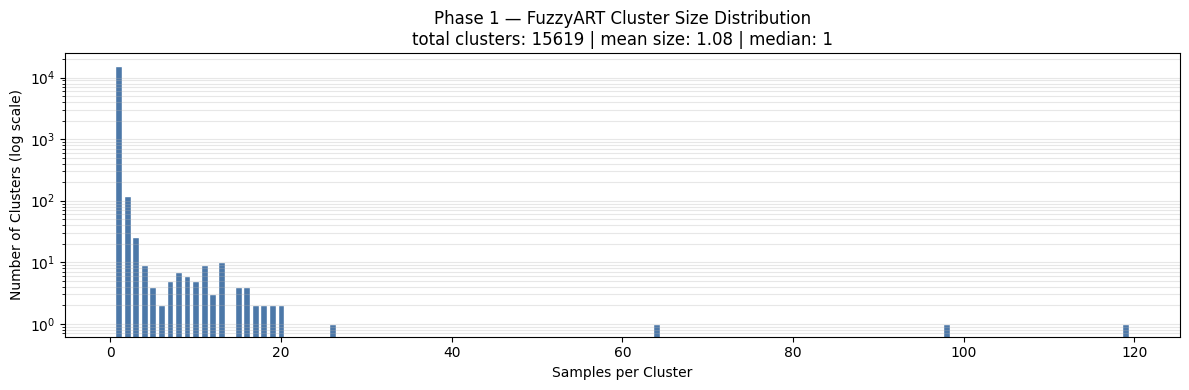

In [10]:
plot_fuzzyart_cluster_sizes(assignments_half1, "Phase 1 — FuzzyART Cluster Size Distribution")

Total clusters found: 15619


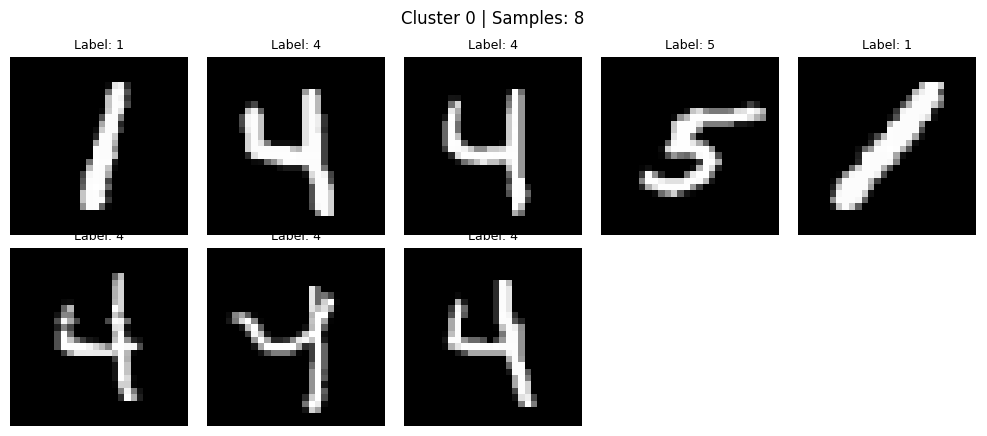

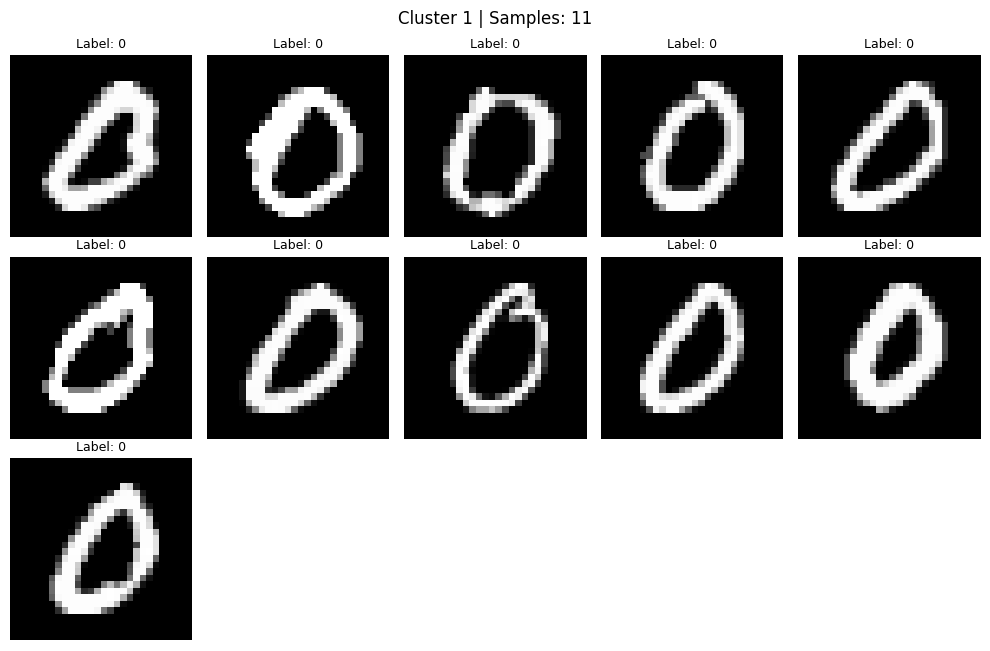

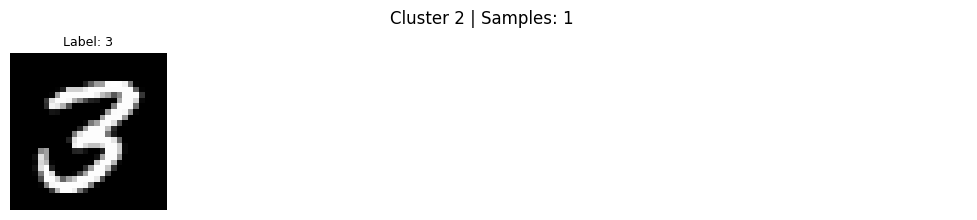

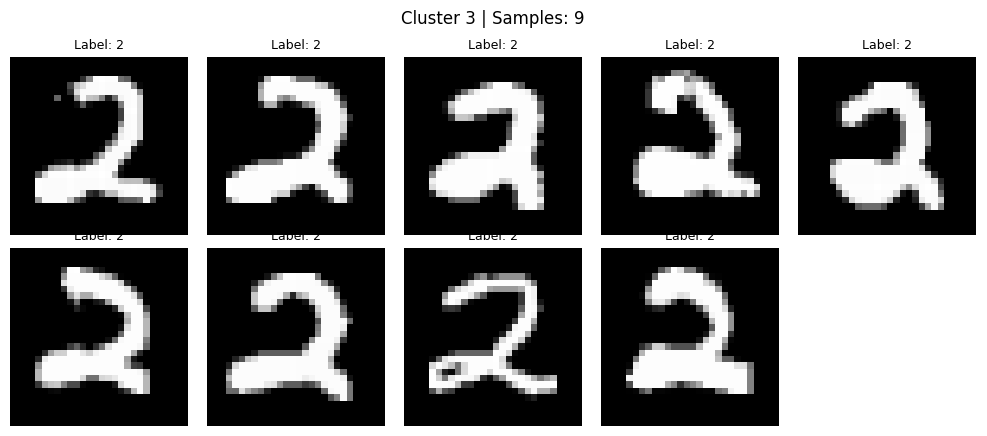

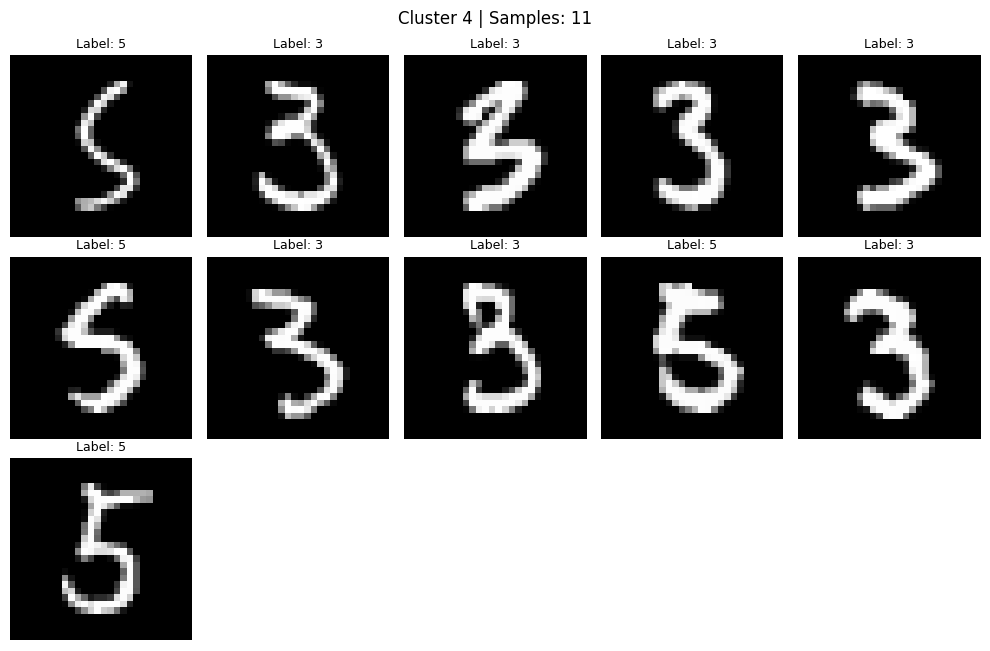

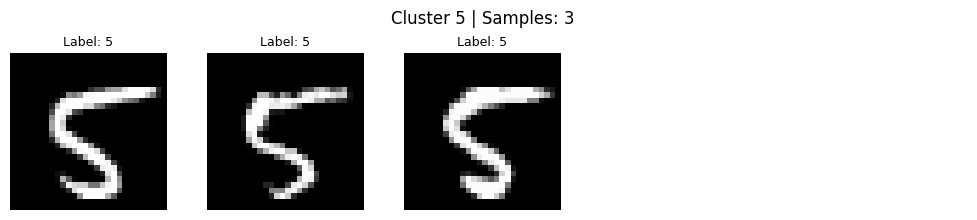

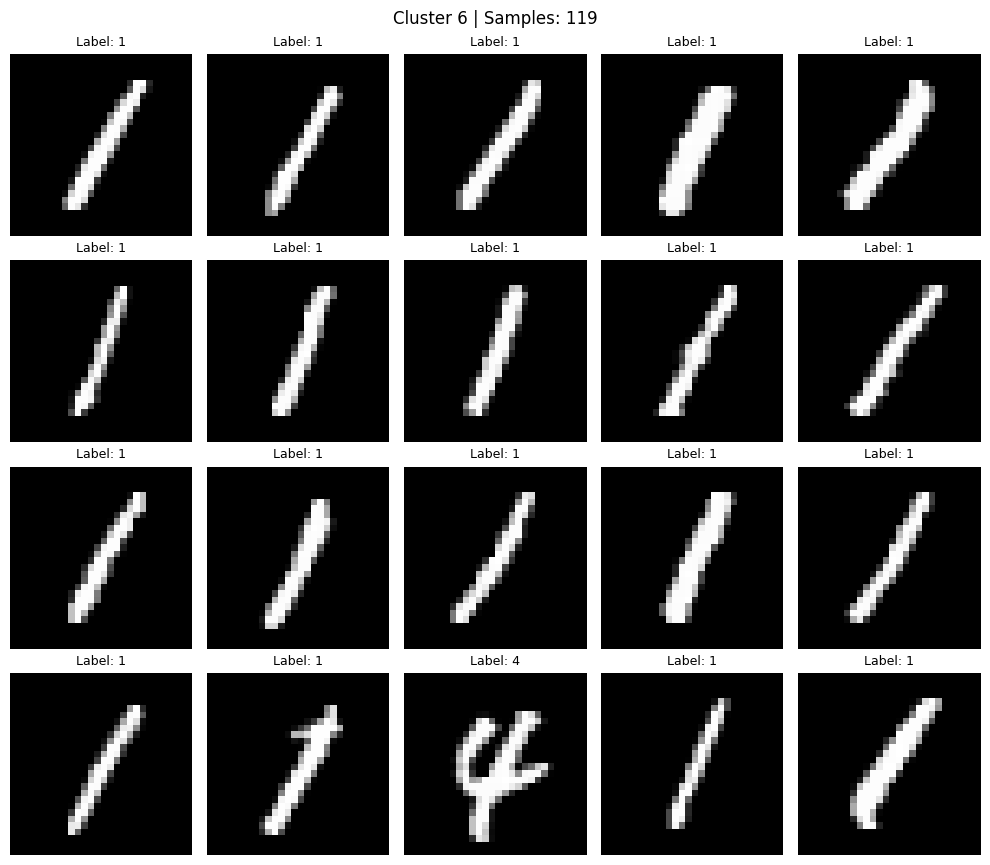

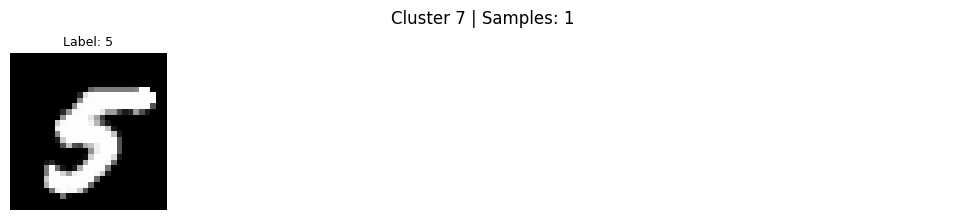

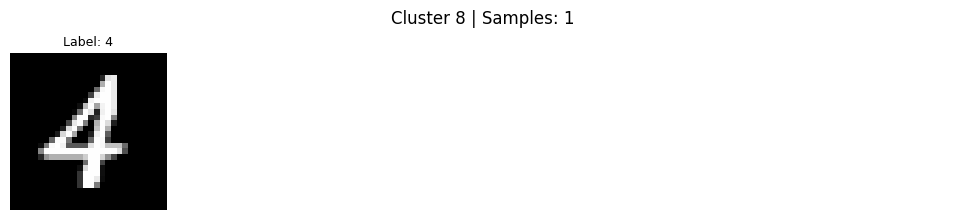

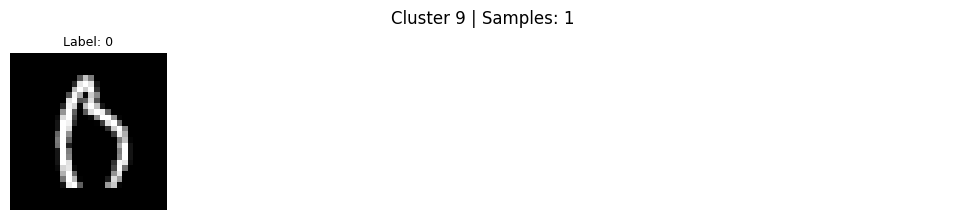

In [11]:
samples_per_cluster = 20
cluster_ids = np.unique(assignments_half1)

print(f"Total clusters found: {len(cluster_ids)}")

for cluster_id in cluster_ids[:10]:
    idx = np.where(assignments_half1 == cluster_id)[0]
    if len(idx) == 0:
        continue

    n_show = min(samples_per_cluster, len(idx))
    show_idx = np.random.choice(idx, size=n_show, replace=False)

    cols = 5
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = np.array(axes).reshape(-1)

    for ax, sample_i in zip(axes, show_idx):
        ax.imshow(X_train_half1[sample_i].reshape(28, 28), cmap="gray")
        ax.set_title(f"Label: {y_train_half1[sample_i]}", fontsize=9)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    fig.suptitle(f"Cluster {cluster_id} | Samples: {len(idx)}", fontsize=12)
    plt.tight_layout()
    plt.show()

- ePNN

In [12]:
# ── Phase 1: ePNN — first half of digits 0–5 ──────────────────────────────
net_epnn = ePNN(
    n_max=500,
    phi_init=0.30,
    t=0.0,
    alpha=0.005,
    fac=1.2,
    s=0.5,
)

for i in range(len(X_epnn_half1)):
    net_epnn.train(X_epnn_half1[i], int(y_train_half1[i]))

train_correct = sum(
    net_epnn.predict(X_epnn_half1[i]) == int(y_train_half1[i])
    for i in range(len(X_epnn_half1))
)
print(f"ePNN train accuracy (Phase 1): {train_correct / len(X_epnn_half1) * 100:.2f}% ({train_correct}/{len(X_epnn_half1)})")

ePNN train accuracy (Phase 1): 90.59% (15237/16819)


### Testing and comparing both models

In [13]:
# ── Phase 1: Evaluation ────────────────────────────────────────────────────
fuzzy_preds_1 = predict_fuzzyart(net_fuzzyart, fuzzyart_label_map, X_test_05)
epnn_preds_1 = predict_epnn(net_epnn, X_epnn_test_05)
print_comparison(epnn_preds_1, fuzzy_preds_1, y_test_05, list(range(6)),
                 "Phase 1 — First Half (Digits 0-5)")


  Phase 1 — First Half (Digits 0-5)

Aggregate (macro-average):
   Model Accuracy Precision Recall F1-score
    ePNN   90.69%    91.02% 90.68%   90.69%
FuzzyART   97.61%    97.63% 97.57%   97.59%

Per-digit metrics:
   Model  Digit Precision Recall F1-score  Support
    ePNN      0    96.82% 92.69%   94.71%     1381
    ePNN      1    99.79% 90.86%   95.11%     1575
    ePNN      2    88.72% 91.13%   89.91%     1398
    ePNN      3    85.46% 89.29%   87.33%     1428
    ePNN      4    98.25%  90.4%   94.16%     1365
    ePNN      5    77.07% 89.71%   82.91%     1263
FuzzyART      0    98.21% 99.42%   98.81%     1381
FuzzyART      1    96.67% 99.56%   98.09%     1575
FuzzyART      2    98.45% 95.49%   96.95%     1398
FuzzyART      3    97.38% 96.15%   96.76%     1428
FuzzyART      4    98.53% 98.02%   98.27%     1365
FuzzyART      5    96.52% 96.75%   96.64%     1263


/tmp/ipykernel_200418/1003338282.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max_kernels)


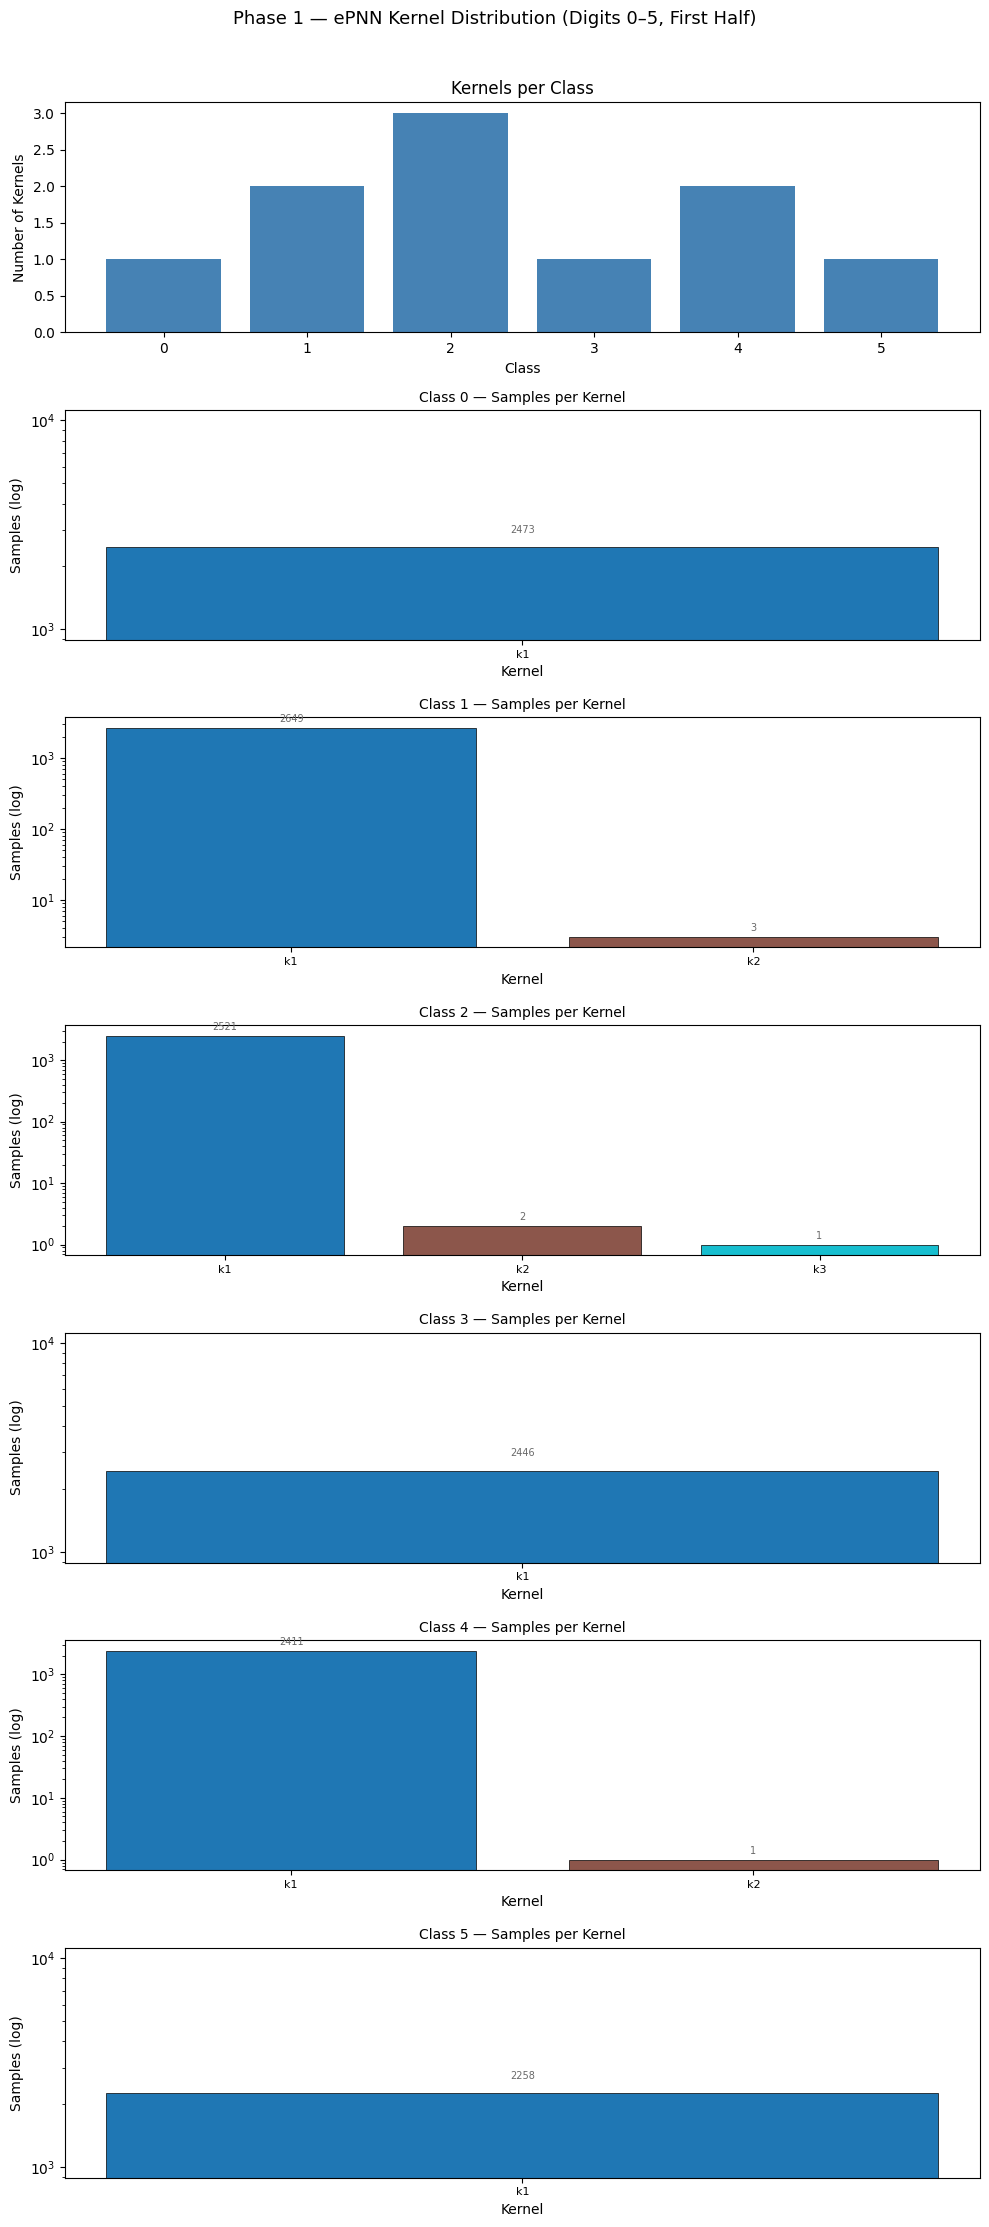

In [14]:
import matplotlib.cm as cm


def plot_epnn_kernels(net, title="ePNN Kernel Distribution"):
    classes = sorted(net.gmms.keys())
    if not classes:
        print("No classes in ePNN.")
        return

    kernels_per_class = [len(net.gmms[c].kernels) for c in classes]
    samples_by_class = [[k.sample_count for k in net.gmms[c].kernels] for c in classes]

    max_kernels = max((len(s) for s in samples_by_class), default=1)
    cmap = cm.get_cmap("tab10", max_kernels)
    kernel_colors = [cmap(i) for i in range(max_kernels)]

    n_classes = len(classes)
    fig, axes = plt.subplots(
        1 + n_classes, 1,
        figsize=(10, 4 + 3 * n_classes),
    )

    axes[0].bar([str(c) for c in classes], kernels_per_class, color="steelblue")
    axes[0].set_title("Kernels per Class")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Number of Kernels")

    for row_idx, (c, samples) in enumerate(zip(classes, samples_by_class), start=1):
        ax = axes[row_idx]
        n_kernels = len(samples)
        x = np.arange(n_kernels)
        colors = [kernel_colors[i] for i in range(n_kernels)]

        bars = ax.bar(x, samples, color=colors, edgecolor="black", linewidth=0.5)

        if samples and max(samples) > 0:
            ax.set_yscale("log")
        ax.set_title(f"Class {c} — Samples per Kernel", fontsize=10)
        ax.set_xlabel("Kernel")
        ax.set_ylabel("Samples (log)")
        ax.set_xticks(x)
        ax.set_xticklabels([f"k{i+1}" for i in x], fontsize=8)

        for bar, val in zip(bars, samples):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    val * 1.15,
                    f"{val}",
                    ha="center", va="bottom", fontsize=7, color="dimgray",
                )

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# Phase 1 kernel analysis
plot_epnn_kernels(net_epnn, title="Phase 1 — ePNN Kernel Distribution (Digits 0–5, First Half)")

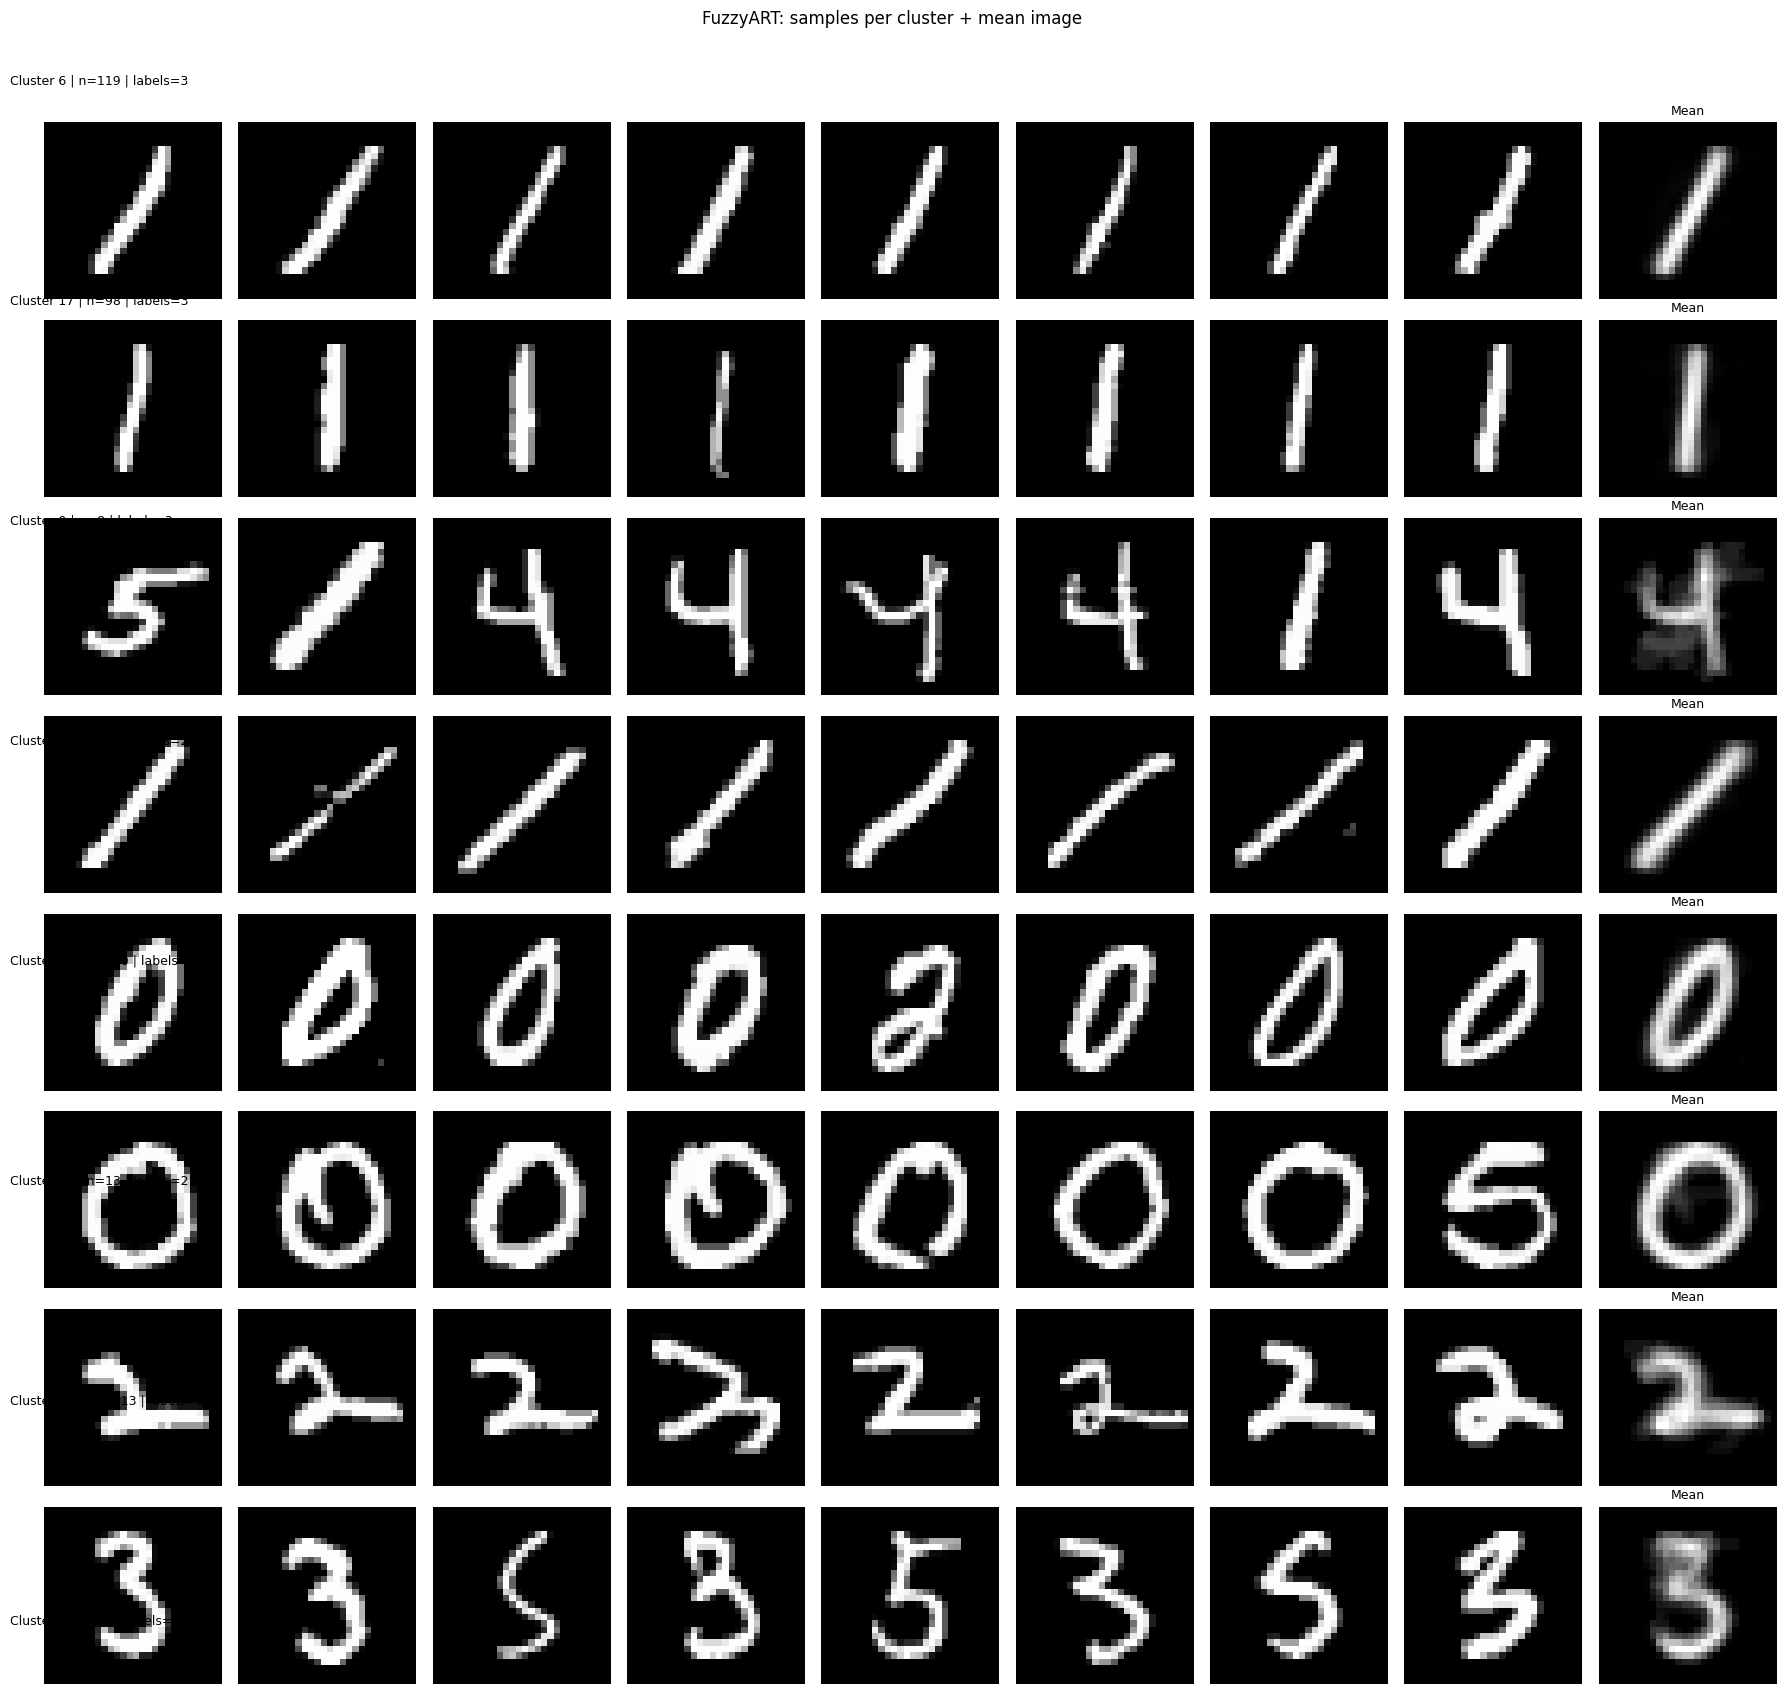

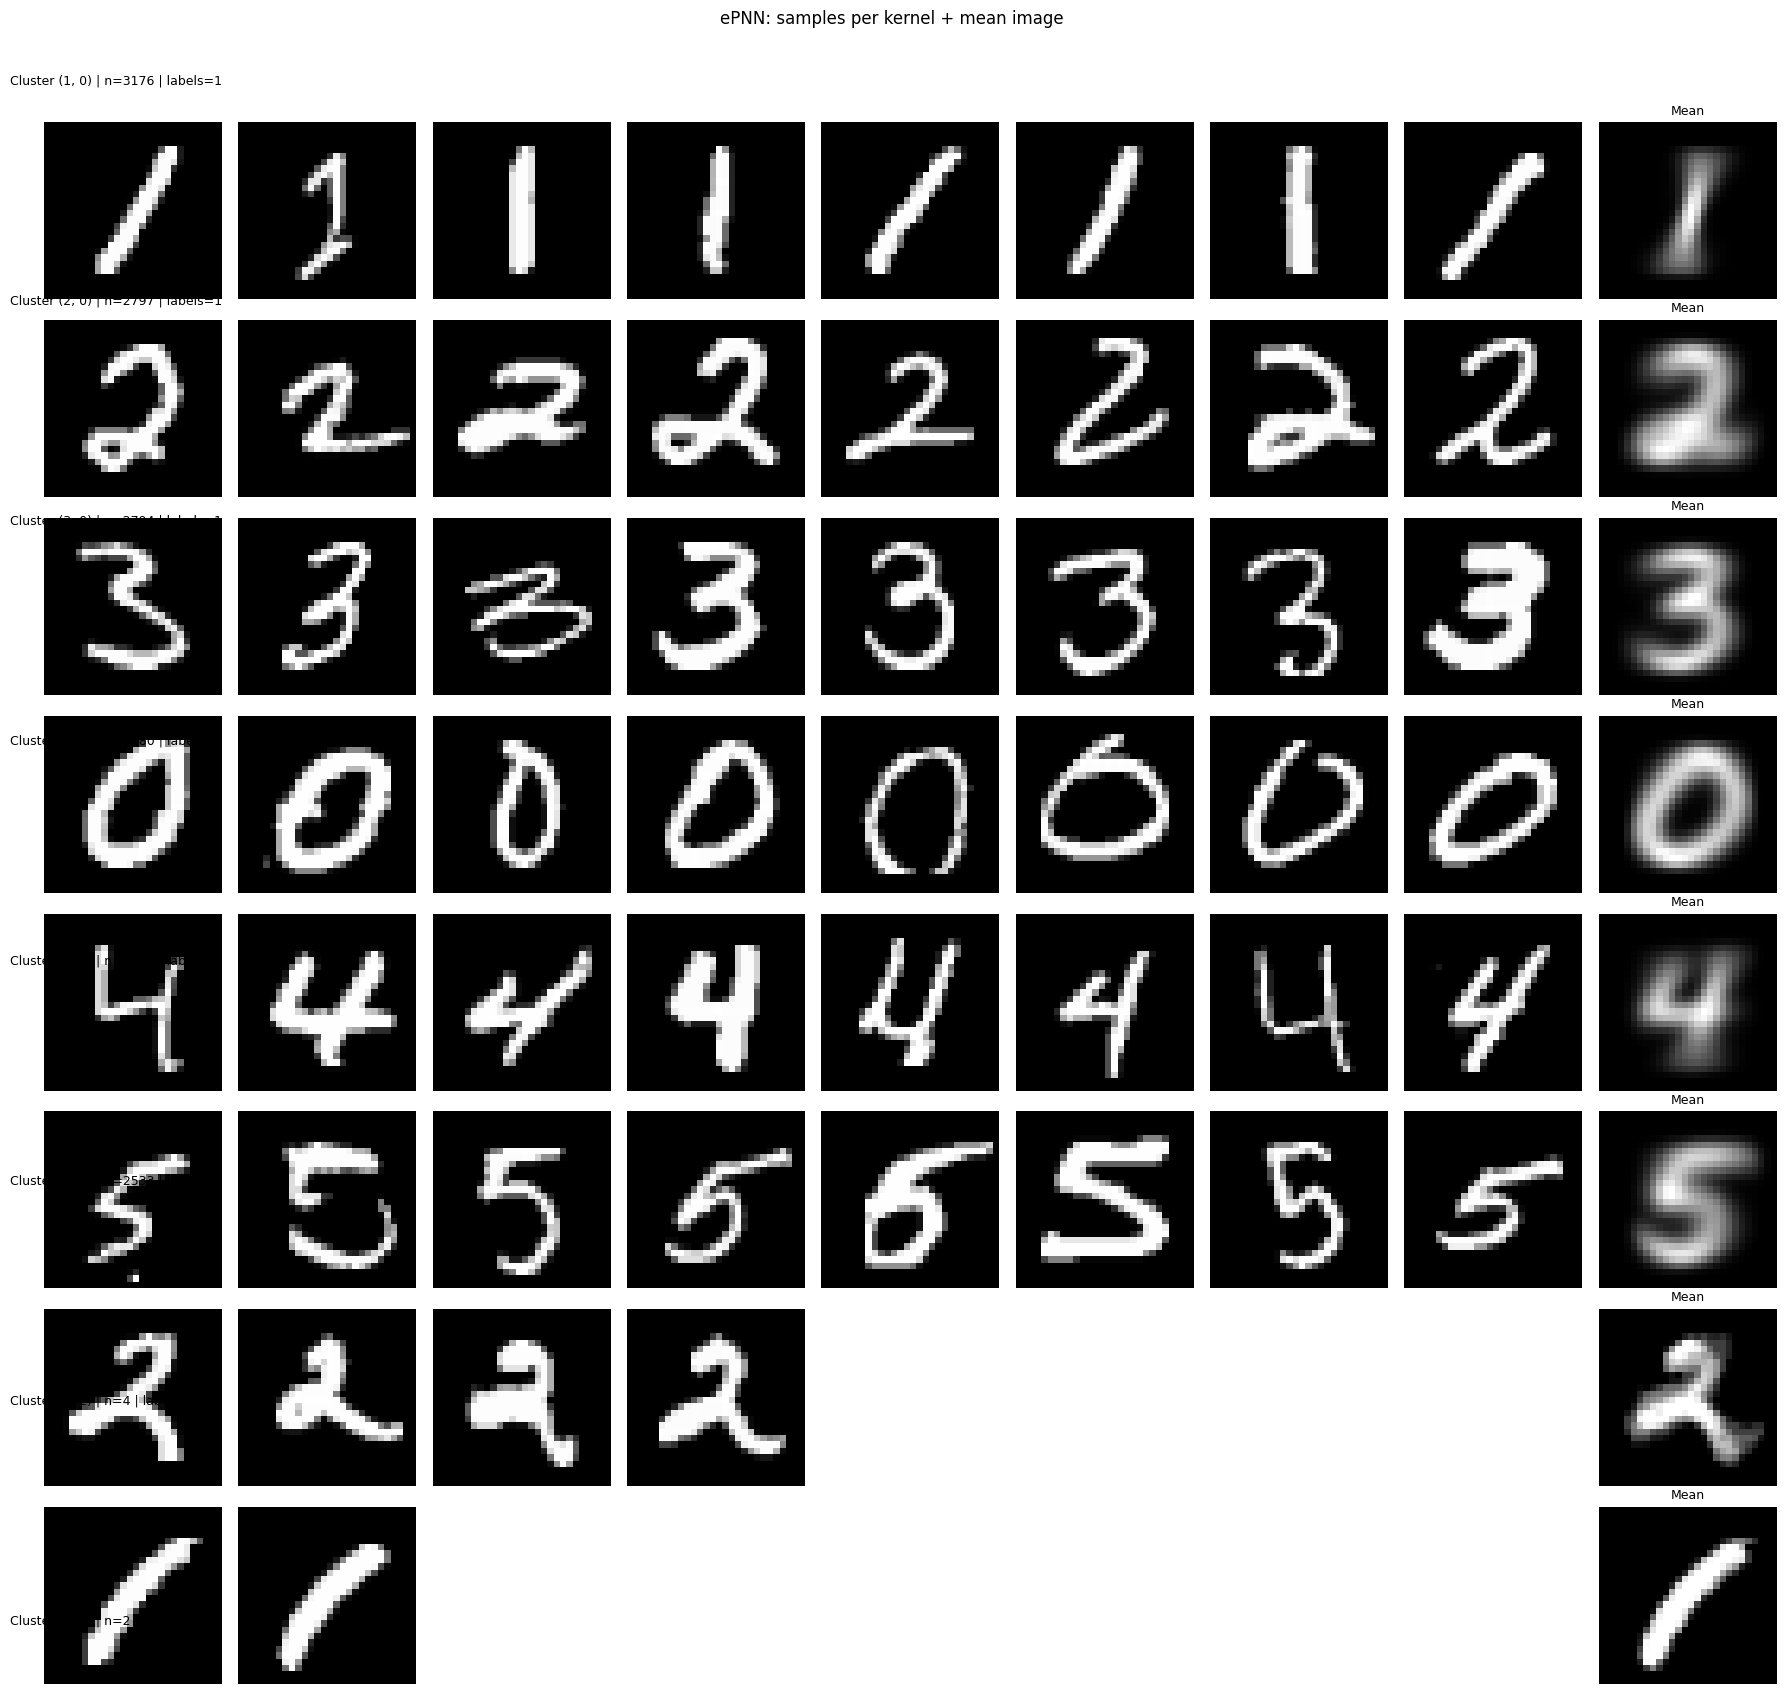

In [15]:
def plot_clusters_with_mean(images, cluster_ids, title, labels=None, max_clusters=8, samples_per_cluster=8):
    groups = {}
    label_array = None if labels is None else np.asarray(labels)
    for i, cid in enumerate(cluster_ids):
        if cid is None:
            continue
        if isinstance(cid, np.ndarray):
            cid = tuple(cid.tolist())
        elif isinstance(cid, list):
            cid = tuple(cid)
        groups.setdefault(cid, []).append(i)
    if not groups:
        print(f"No clusters found for {title}.")
        return
    scored_clusters = []
    for cid, idxs in groups.items():
        idxs = np.array(idxs)
        diversity = 0 if label_array is None else len(np.unique(label_array[idxs]))
        scored_clusters.append((cid, idxs, diversity, len(idxs)))
    scored_clusters.sort(key=lambda item: (-item[2], -item[3]))
    scored_clusters = scored_clusters[:max_clusters]
    cols = samples_per_cluster + 1
    rows = len(scored_clusters)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.0, rows * 2.2))
    if rows == 1:
        axes = np.array([axes])
    for row_idx, (cid, idxs, diversity, cluster_size) in enumerate(scored_clusters):
        n_show = min(samples_per_cluster, len(idxs))
        show_idx = np.random.choice(idxs, size=n_show, replace=False)
        for col in range(samples_per_cluster):
            ax = axes[row_idx, col]
            ax.axis("off")
            if col < n_show:
                ax.imshow(images[show_idx[col]].reshape(28, 28), cmap="gray")
        mean_img = images[idxs].mean(axis=0).reshape(28, 28)
        ax_mean = axes[row_idx, -1]
        ax_mean.imshow(mean_img, cmap="gray")
        ax_mean.set_title("Mean", fontsize=9)
        ax_mean.axis("off")
        subtitle = f"Cluster {cid} | n={cluster_size}" if label_array is None else f"Cluster {cid} | n={cluster_size} | labels={diversity}"
        fig.text(0.01, (rows - row_idx - 0.5) / rows, subtitle, fontsize=9)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0.02, 0.02, 1, 0.95])
    plt.show()


# ---- FuzzyART clusters ----
plot_clusters_with_mean(
    X_train_half1,
    assignments_half1,
    labels=y_train_half1,
    title="FuzzyART: samples per cluster + mean image",
    max_clusters=8,
    samples_per_cluster=8,
)

# ---- ePNN kernels (cluster = (class_label, kernel_index)) ----
def assign_epnn_kernels(net, X_epnn, y_labels):
    cluster_ids = []
    for i, x in enumerate(X_epnn):
        label = int(y_labels[i])
        gmm = net.gmms.get(label)
        if gmm is None or not gmm.kernels:
            cluster_ids.append(None)
            continue
        acts = [gmm._activation(x, k) * k.weight for k in gmm.kernels]
        k_idx = int(np.argmax(acts))
        cluster_ids.append((label, k_idx))
    return np.array(cluster_ids, dtype=object)

epnn_cluster_ids = assign_epnn_kernels(net_epnn, X_epnn_half1, y_train_half1)
plot_clusters_with_mean(
    X_train_half1,
    epnn_cluster_ids,
    labels=y_train_half1,
    title="ePNN: samples per kernel + mean image",
    max_clusters=8,
    samples_per_cluster=8,
)

### Training: 2nd half of digits 0 - 5

- Fuzzy Art

In [16]:
# ── Phase 2: FuzzyART — second half of digits 0–5 (incremental) ───────────
assignments_half2 = np.full(len(X_train_half2), -1, dtype=np.int32)
for i, x in enumerate(X_train_half2):
    try:
        assignments_half2[i] = net_fuzzyart.train(x)
    except RuntimeError as e:
        assignments_half2 = assignments_half2[:i]
        print(f"Stopped at sample {i}: {e}")
        break

print(f"Active clusters after Phase 2: {net_fuzzyart.num_clusters}")

# Rebuild label map from all digits 0-5 training data
all_assignments_05 = np.concatenate([assignments_half1, assignments_half2])
all_y_train_05 = np.concatenate([y_train_half1, y_train_half2])
fuzzyart_label_map = build_cluster_label_map(all_assignments_05, all_y_train_05)

Active clusters after Phase 2: 31925


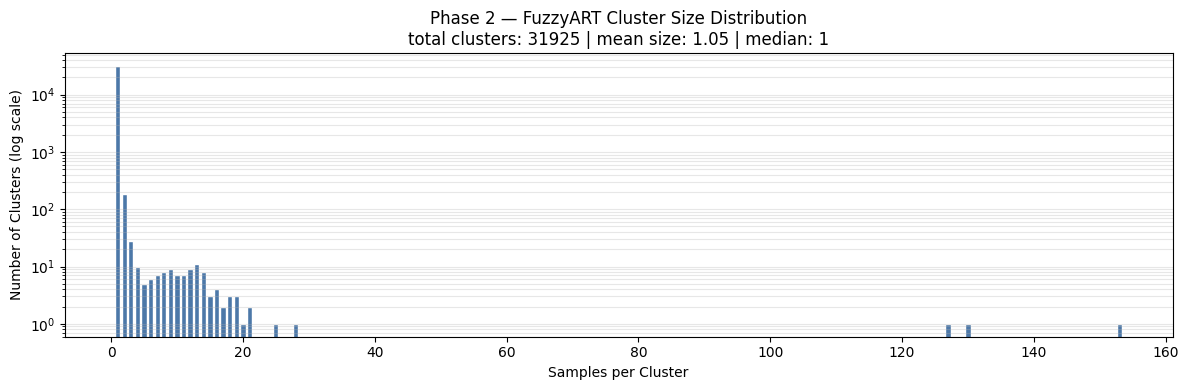

In [17]:
plot_fuzzyart_cluster_sizes(all_assignments_05, "Phase 2 — FuzzyART Cluster Size Distribution")

- ePNN

In [18]:
# ── Phase 2: ePNN — second half of digits 0–5 (incremental) ───────────────
for i in range(len(X_epnn_half2)):
    net_epnn.train(X_epnn_half2[i], int(y_train_half2[i]))

train_correct = sum(
    net_epnn.predict(X_epnn_half2[i]) == int(y_train_half2[i])
    for i in range(len(X_epnn_half2))
)
print(f"ePNN train accuracy (Phase 2, 2nd half): {train_correct / len(X_epnn_half2) * 100:.2f}% ({train_correct}/{len(X_epnn_half2)})")

ePNN train accuracy (Phase 2, 2nd half): 90.72% (15259/16819)


/tmp/ipykernel_200418/1003338282.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max_kernels)


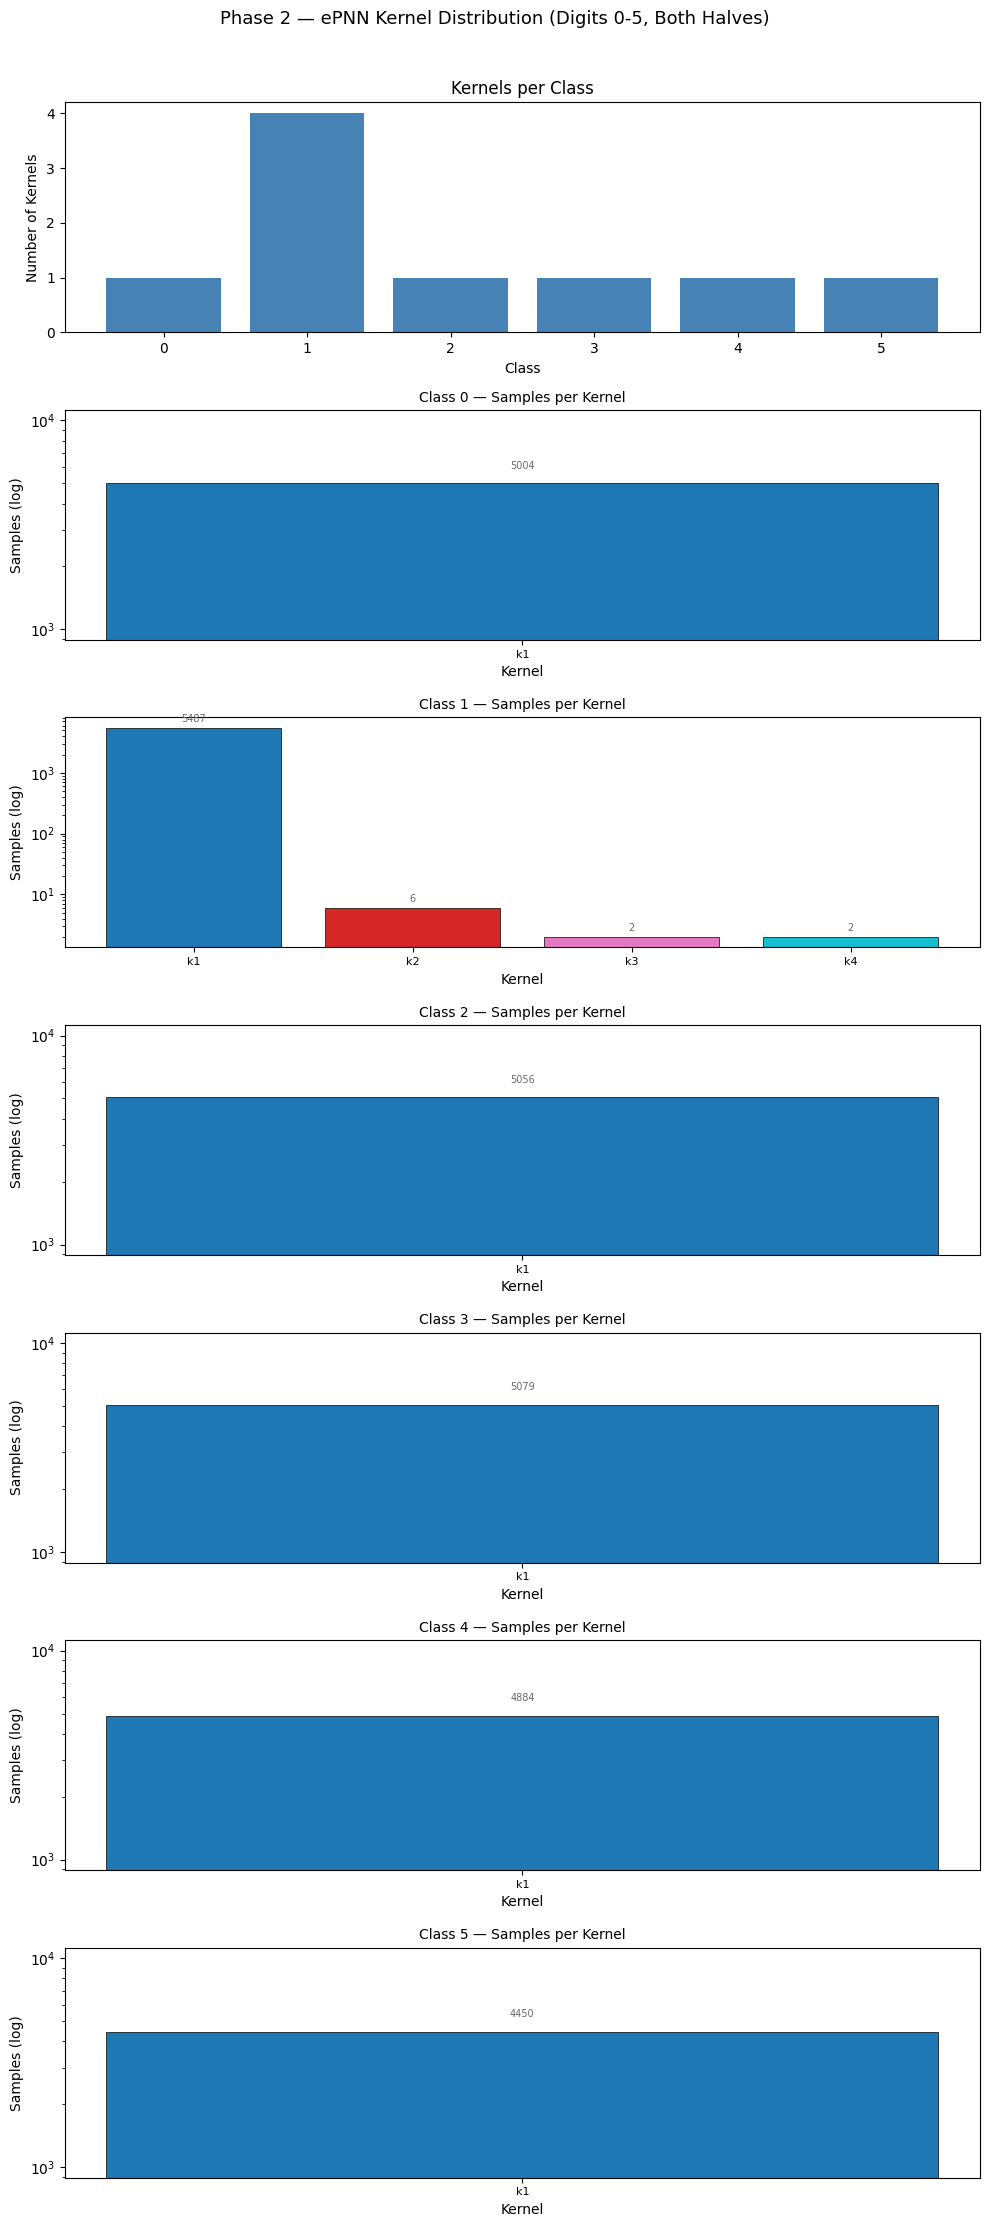

In [19]:
plot_epnn_kernels(net_epnn, title="Phase 2 — ePNN Kernel Distribution (Digits 0-5, Both Halves)")

### Testing and comparing both models

In [20]:
# ── Phase 2: Evaluation ────────────────────────────────────────────────────
fuzzy_preds_2 = predict_fuzzyart(net_fuzzyart, fuzzyart_label_map, X_test_05)
epnn_preds_2 = predict_epnn(net_epnn, X_epnn_test_05)
print_comparison(epnn_preds_2, fuzzy_preds_2, y_test_05, list(range(6)),
                 "Phase 2 — Second Half (Digits 0-5, Incremental)")


  Phase 2 — Second Half (Digits 0-5, Incremental)

Aggregate (macro-average):
   Model Accuracy Precision Recall F1-score
    ePNN   90.69%    91.09% 90.65%   90.67%
FuzzyART   97.73%    97.73% 97.69%    97.7%

Per-digit metrics:
   Model  Digit Precision Recall F1-score  Support
    ePNN      0    97.14% 91.09%   94.02%     1381
    ePNN      1    99.79% 92.44%   95.98%     1575
    ePNN      2    87.93% 93.28%   90.52%     1398
    ePNN      3    88.06% 87.25%   87.65%     1428
    ePNN      4    98.31%  89.6%   93.75%     1365
    ePNN      5     75.3% 90.26%    82.1%     1263
FuzzyART      0    98.78% 99.49%   99.13%     1381
FuzzyART      1    97.09% 99.56%   98.31%     1575
FuzzyART      2    97.69%  97.0%   97.34%     1398
FuzzyART      3    97.69% 94.75%    96.2%     1428
FuzzyART      4    99.04% 98.46%   98.75%     1365
FuzzyART      5    96.08% 96.91%   96.49%     1263


### Training: Adding digits 6 - 9

- Fuzzy Art

In [21]:
# ── Phase 3: FuzzyART — new classes, digits 6–9 (incremental) ─────────────
assignments_69 = np.full(len(X_train_69), -1, dtype=np.int32)
for i, x in enumerate(X_train_69):
    try:
        assignments_69[i] = net_fuzzyart.train(x)
    except RuntimeError as e:
        assignments_69 = assignments_69[:i]
        print(f"Stopped at sample {i}: {e}")
        break

print(f"Active clusters after Phase 3: {net_fuzzyart.num_clusters}")

# Rebuild label map from all training data (digits 0-9)
all_assignments = np.concatenate([all_assignments_05, assignments_69])
all_y_train = np.concatenate([all_y_train_05, y_train_69])
fuzzyart_label_map = build_cluster_label_map(all_assignments, all_y_train)

Active clusters after Phase 3: 53556


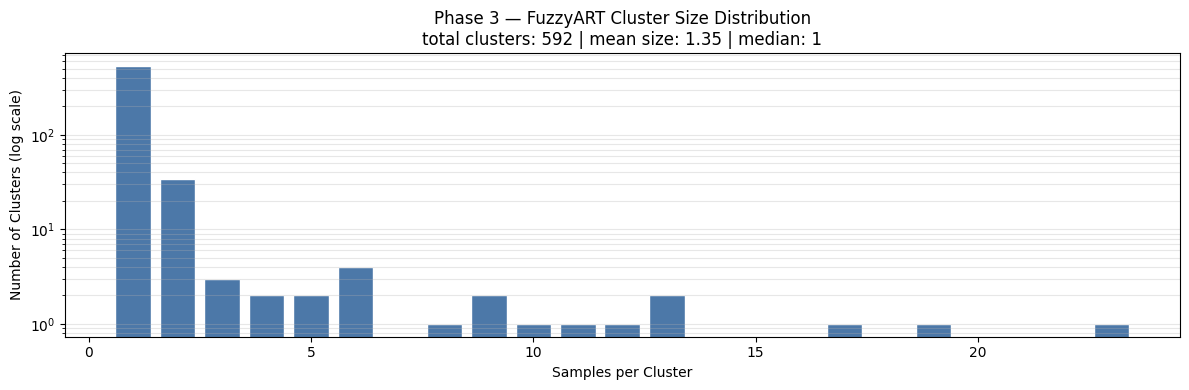

In [64]:
plot_fuzzyart_cluster_sizes(all_assignments, "Phase 3 — FuzzyART Cluster Size Distribution")

- ePNN

In [22]:
# ── Phase 3: ePNN — new classes, digits 6–9 (incremental) ─────────────────
for i in range(len(X_epnn_train_69)):
    net_epnn.train(X_epnn_train_69[i], int(y_train_69[i]))

train_correct = sum(
    net_epnn.predict(X_epnn_train_69[i]) == int(y_train_69[i])
    for i in range(len(X_epnn_train_69))
)
print(f"ePNN train accuracy (Phase 3, digits 6-9): {train_correct / len(X_epnn_train_69) * 100:.2f}% ({train_correct}/{len(X_epnn_train_69)})")

ePNN train accuracy (Phase 3, digits 6-9): 90.03% (20131/22361)


/tmp/ipykernel_200418/1003338282.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", max_kernels)


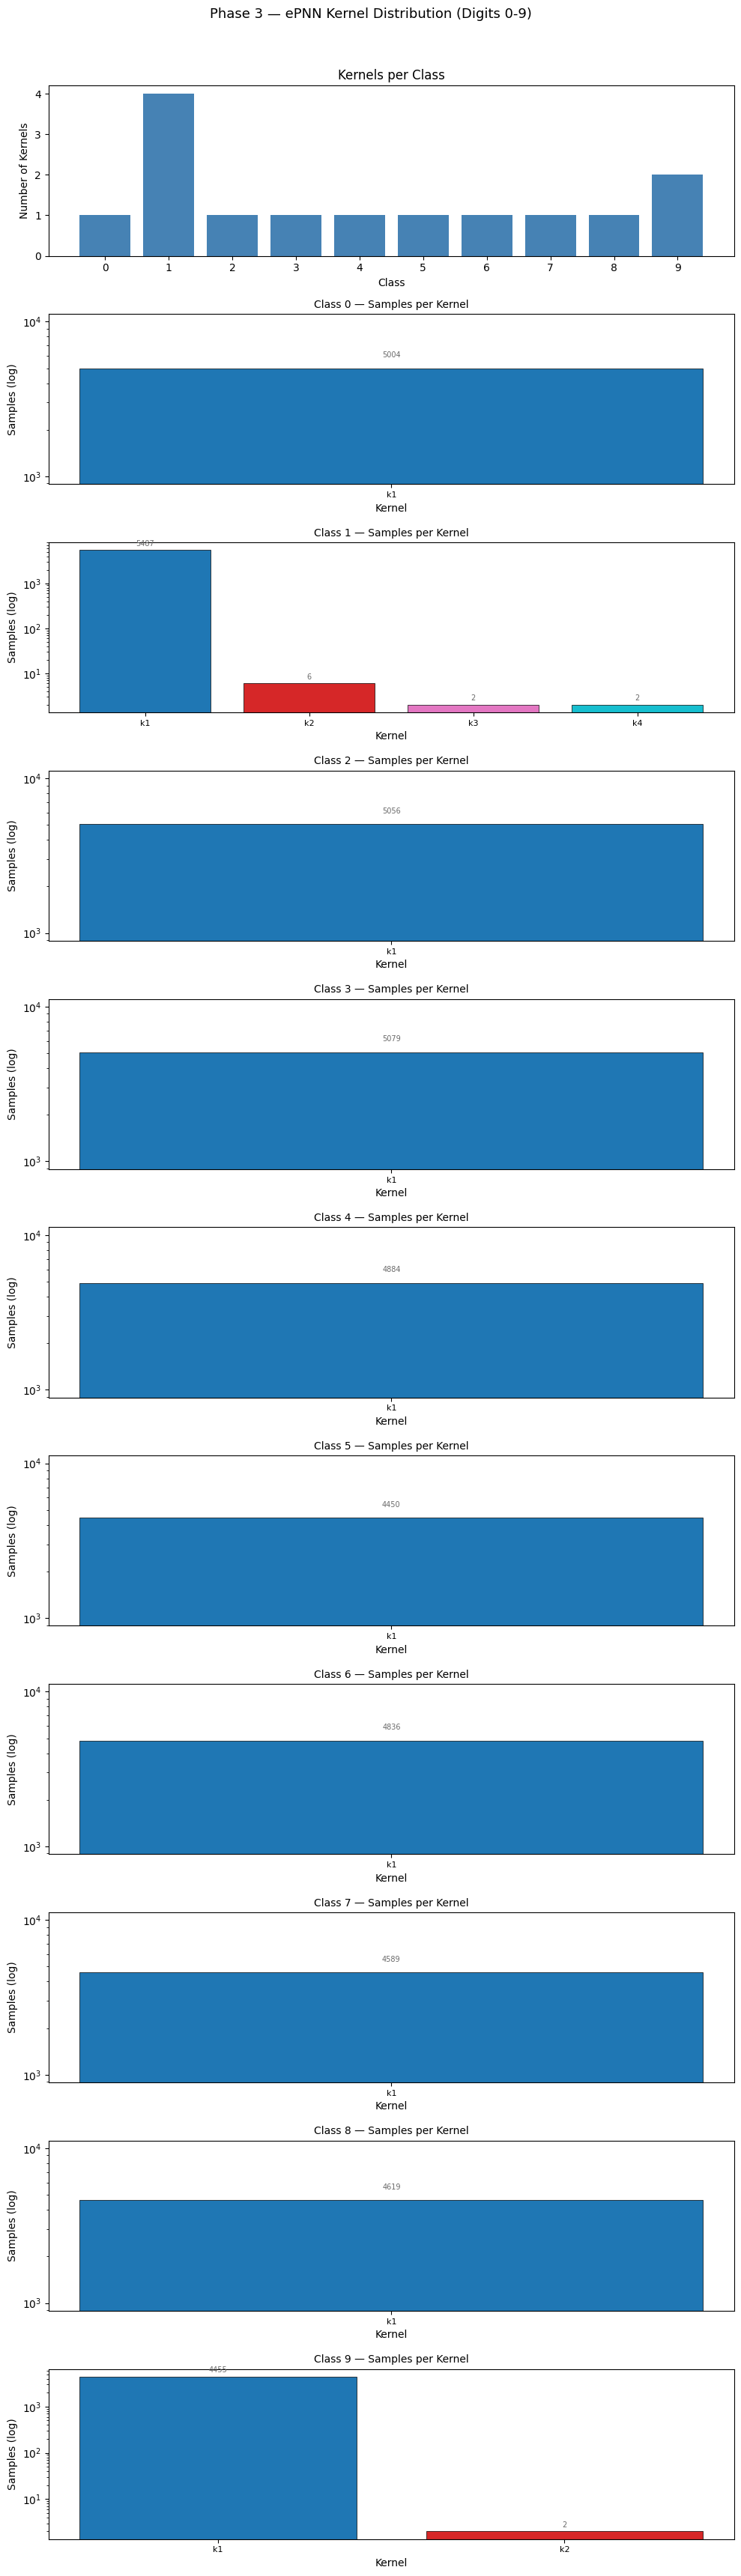

In [23]:
plot_epnn_kernels(net_epnn, title="Phase 3 — ePNN Kernel Distribution (Digits 0-9)")

### Testing and comparing both models

In [ ]:
# ── Phase 3: Evaluation ────────────────────────────────────────────────────
X_test_all = np.concatenate([X_test_05, X_test_69])
y_test_all = np.concatenate([y_test_05, y_test_69])
X_epnn_test_all = np.concatenate([X_epnn_test_05, X_epnn_test_69])

fuzzy_preds_3 = predict_fuzzyart(net_fuzzyart, fuzzyart_label_map, X_test_all)
epnn_preds_3 = predict_epnn(net_epnn, X_epnn_test_all)
print_comparison(epnn_preds_3, fuzzy_preds_3, y_test_all, list(range(10)),
                 "Phase 3 — New Classes (Digits 6-9, Incremental)")


  Phase 3 — New Classes (Digits 6-9, Incremental)

Aggregate (macro-average):
   Model Accuracy Precision Recall F1-score
    ePNN   80.87%    84.28% 80.65%   80.99%
FuzzyART   95.89%    95.92% 95.82%   95.85%

Per-digit metrics:
   Model  Digit Precision Recall F1-score  Support
    ePNN      0    97.48% 84.07%   90.28%     1381
    ePNN      1    99.09% 89.71%   94.17%     1575
    ePNN      2    90.67% 75.75%   82.54%     1398
    ePNN      3    86.77% 73.95%   79.85%     1428
    ePNN      4    97.72% 56.48%   71.59%     1365
    ePNN      5    77.37% 69.28%    73.1%     1263
    ePNN      6    83.98% 93.38%   88.43%     1375
    ePNN      7    91.42% 83.28%   87.16%     1459
    ePNN      8    56.19% 91.79%   69.71%     1365
    ePNN      9    62.08% 88.79%   73.07%     1392
FuzzyART      0    97.99% 99.06%   98.52%     1381
FuzzyART      1    94.85% 99.37%   97.05%     1575
FuzzyART      2    95.84% 95.49%   95.66%     1398
FuzzyART      3     95.7%  95.1%    95.4%     1428
Fuzz

### Training and testing MiniBatchKMeans with the whole dataset

In [28]:
import time
import numpy as np
from sklearn.cluster import MiniBatchKMeans

data = {}

t0 = time.time()

for i in range(10):
    data[i] = {
        "images": np.array([img for img, lbl in zip(X_train, y_train) if lbl == i]),
        "clusters": MiniBatchKMeans(n_clusters=15, n_init=5),
    }
    data[i]['clusters'].fit(data[i]['images'])

dt = time.time() - t0
print("done in %.2fs." % dt)

done in 7.76s.


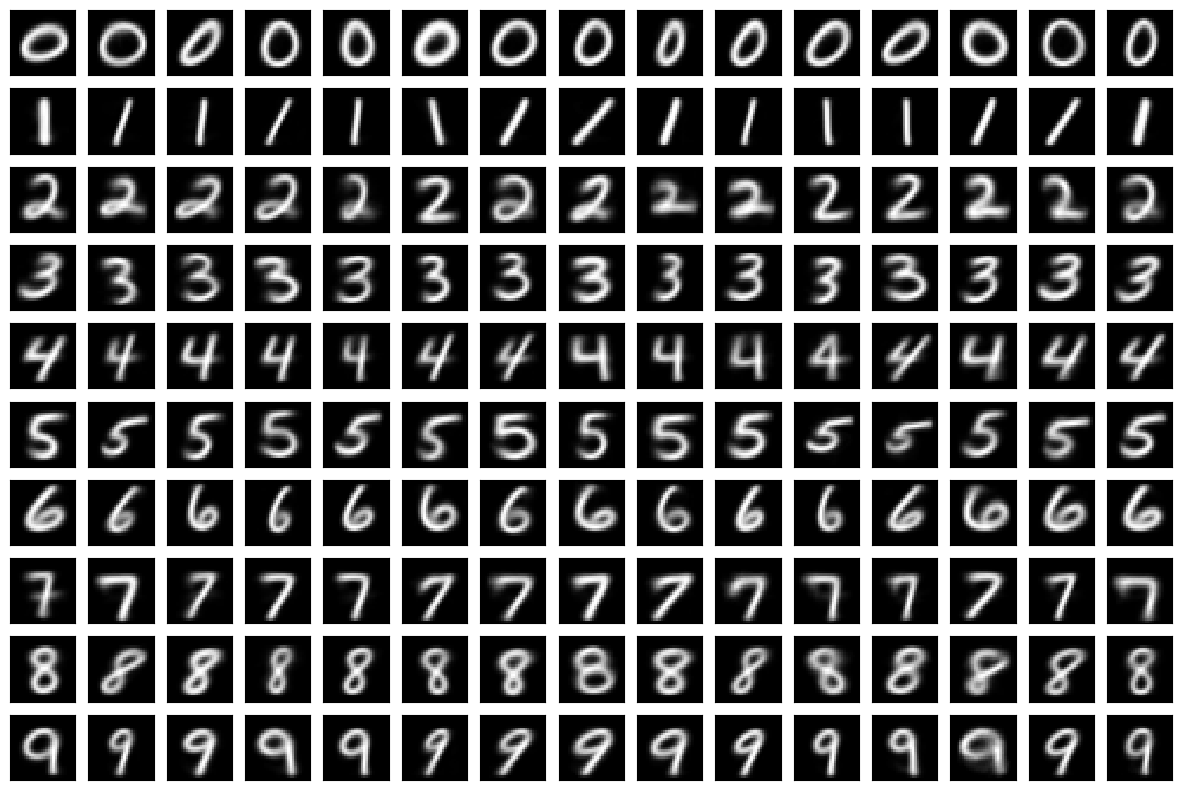

In [29]:
plt.close('all')
plt.figure(figsize=(15, 10))
for lbl in range(10):
    cluters = data[lbl]['clusters']
    for c_idx in range(len(cluters.cluster_centers_)):
        plt.subplot(10, 15, lbl * 15 + c_idx + 1)
        plt.imshow(cluters.cluster_centers_[c_idx].reshape((28, 28)), cmap='gray', interpolation="nearest")
        plt.xticks(())
        plt.yticks(())

plt.show()

In [30]:
from sklearn.metrics import classification_report

prd = []
true = []

for img, true_lbl in zip(X_test, y_test):
    true.append(true_lbl)
    min_dist = np.inf
    prd_lbl = -1
    for lbl in range(10):
        for c in data[lbl]['clusters'].cluster_centers_:
            d = np.linalg.norm(img - c)
            if d < min_dist:
                min_dist = d
                prd_lbl = lbl
    prd.append(prd_lbl)

print(classification_report(true, prd))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1381
           1       0.94      0.98      0.96      1575
           2       0.95      0.92      0.94      1398
           3       0.91      0.90      0.90      1428
           4       0.93      0.88      0.90      1365
           5       0.90      0.90      0.90      1263
           6       0.95      0.97      0.96      1375
           7       0.94      0.92      0.93      1459
           8       0.91      0.90      0.90      1365
           9       0.85      0.89      0.87      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



In [13]:
n = 40
pca_ = PCA(n_components=n, random_state=42)
scaler_ = StandardScaler()

# Fit only on the first half; transform everything else with the same transform
X_train = scaler_.fit_transform(pca_.fit_transform(X_train))
X_test = scaler_.transform(pca_.transform(X_test))

In [19]:
epnn = ePNN(
    n_max=500,
    phi_init=0.30,
    t=0.0,
    alpha=0.005,
    fac=1.2,
    s=0.5,
)

for i in range(len(X_train)):
    epnn.train(X_train[i], int(y_train[i]))

train_corr = sum(
    epnn.predict(X_train[i]) == int(y_train[i])
    for i in range(len(X_train))
)
print(f"ePNN train accuracy: {train_corr / len(X_train) * 100:.2f}% ({train_corr}/{len(X_train)})")

ePNN train accuracy: 85.13% (47674/56000)


In [23]:
preds = predict_epnn(epnn, X_test)
report = classification_report(y_test, preds)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      1381
           1       0.99      0.86      0.92      1575
           2       0.78      0.88      0.83      1398
           3       0.86      0.82      0.84      1428
           4       0.94      0.77      0.84      1365
           5       0.65      0.85      0.74      1263
           6       0.94      0.87      0.91      1375
           7       0.94      0.86      0.90      1459
           8       0.74      0.87      0.80      1365
           9       0.80      0.83      0.81      1391

    accuracy                           0.85     14000
   macro avg       0.86      0.85      0.85     14000
weighted avg       0.87      0.85      0.85     14000



Vigilance | Clusters | Mean size | Accuracy
  0.10  |       1  |  16819.00  |  18.73%
  0.20  |       1  |  16819.00  |  18.73%
  0.30  |    1753  |     9.59  |  32.02%
  0.40  |   12738  |     1.32  |  86.30%
  0.50  |   16720  |     1.01  |  97.81%
  0.60  |   16642  |     1.01  |  97.73%
  0.70  |   15430  |     1.09  |  97.28%
  0.80  |   15619  |     1.08  |  97.61%
  0.90  |   14072  |     1.20  |  97.67%
  0.93  |   13955  |     1.21  |  97.18%
  0.95  |   15163  |     1.11  |  97.18%
  0.97  |   16230  |     1.04  |  97.59%
  0.99  |   16710  |     1.01  |  97.82%


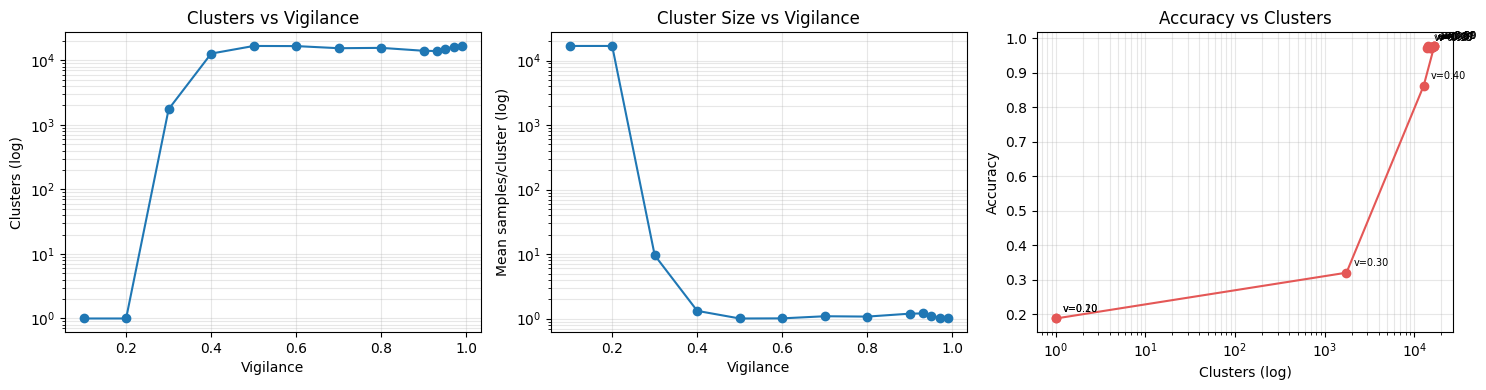

In [25]:
# ── Vigilance sweep: accuracy vs cluster count (FuzzyART) ─────────────────
vigilance_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.93, 0.95, 0.97, 0.99]
sweep_results = {}

for v in vigilance_values:
    net_v = FuzzyART(
        num_features=X_train_half1.shape[1],
        max_clusters=100_000,
        vigilance=v,
        learning_rate=0.5,
        alpha=0.01,
        complement=True,
    )
    v_assignments = []
    for x in X_train_half1:
        try:
            v_assignments.append(net_v.train(x))
        except RuntimeError:
            break
    v_assignments = np.array(v_assignments, dtype=np.int32)
    y_subset = y_train_half1[:len(v_assignments)]

    # Build label map and evaluate on test set
    v_label_map = build_cluster_label_map(v_assignments, y_subset)
    correct = sum(
        v_label_map.get(net_v.predict(x), -999) == y_test_05[i]
        for i, x in enumerate(X_test_05)
    )
    counts = np.array([np.sum(v_assignments == cid) for cid in np.unique(v_assignments)])
    sweep_results[v] = {
        "num_clusters": net_v.num_clusters,
        "mean_cluster_size": float(np.mean(counts)) if len(counts) else 0.0,
        "accuracy": correct / len(X_test_05),
    }

print("Vigilance | Clusters | Mean size | Accuracy")
for v, r in sweep_results.items():
    print(f"  {v:.2f}  |  {r['num_clusters']:6d}  |  {r['mean_cluster_size']:7.2f}  |  {r['accuracy'] * 100:.2f}%")

# Vigilance vs clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vs = list(sweep_results.keys())
axes[0].plot(vs, [sweep_results[v]["num_clusters"] for v in vs], marker="o")
axes[0].set_yscale("log")
axes[0].set_xlabel("Vigilance"); axes[0].set_ylabel("Clusters (log)"); axes[0].set_title("Clusters vs Vigilance")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].plot(vs, [sweep_results[v]["mean_cluster_size"] for v in vs], marker="o")
axes[1].set_yscale("log")
axes[1].set_xlabel("Vigilance"); axes[1].set_ylabel("Mean samples/cluster (log)"); axes[1].set_title("Cluster Size vs Vigilance")
axes[1].grid(True, which="both", alpha=0.3)

ncs = [sweep_results[v]["num_clusters"] for v in vs]
accs = [sweep_results[v]["accuracy"] for v in vs]
axes[2].plot(ncs, accs, marker="o", color="#E45756")
for v, nc, acc in zip(vs, ncs, accs):
    axes[2].annotate(f"v={v:.2f}", (nc, acc), textcoords="offset points", xytext=(5, 5), fontsize=7)
axes[2].set_xscale("log")
axes[2].set_xlabel("Clusters (log)"); axes[2].set_ylabel("Accuracy"); axes[2].set_title("Accuracy vs Clusters")
axes[2].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()